In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
iris = load_iris()

X = iris.data
y = iris.target.reshape(-1, 1)

classes = iris.target_names

encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


In [3]:
def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()

    model.add(
        Dense(
            hidden_layers[0],
            input_dim=input_dim,
            activation=activation
        )
    )

    for units in hidden_layers[1:]:
        model.add(
            Dense(
                units,
                activation=activation
            )
        )

    model.add(
        Dense(
            output_dim,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

def create_mlp(input_dim, output_dim, hidden_layers, activation='relu'):
    model = Sequential()

    model.add(Input(shape=(input_dim,)))

    model.add(
        Dense(
            hidden_layers[0],
            activation=activation
        )
    )

    for units in hidden_layers[1:]:
        model.add(
            Dense(
                units,
                activation=activation
            )
        )

    model.add(
        Dense(
            output_dim,
            activation='softmax'
        )
    )

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [6]:
hidden_layer_configs = [
    [8],
    [16, 8],
    [32, 16, 8]
]

activations = [
    'relu',
    'tanh',
    'sigmoid'
]

for hidden_layers in hidden_layer_configs:

    for activation in activations:

        print(
            f"\nTesting MLP with hidden_layers={hidden_layers}, "
            f"activation={activation}"
        )

        model = create_mlp(
            input_dim=4,
            output_dim=3,
            hidden_layers=hidden_layers,
            activation=activation
        )

        history = model.fit(
            X_train,
            y_train,
            epochs=50,
            batch_size=5,
            verbose=0,
            validation_split=0.1
        )

        test_loss, test_acc = model.evaluate(
            X_test,
            y_test,
            verbose=0
        )

        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")


Testing MLP with hidden_layers=[8], activation=relu
Test Accuracy: 0.9333
Test Loss: 0.2145

Testing MLP with hidden_layers=[8], activation=tanh
Test Accuracy: 0.9667
Test Loss: 0.1659

Testing MLP with hidden_layers=[8], activation=sigmoid
Test Accuracy: 0.9000
Test Loss: 0.4650

Testing MLP with hidden_layers=[16, 8], activation=relu
Test Accuracy: 1.0000
Test Loss: 0.0630

Testing MLP with hidden_layers=[16, 8], activation=tanh
Test Accuracy: 1.0000
Test Loss: 0.0661

Testing MLP with hidden_layers=[16, 8], activation=sigmoid
Test Accuracy: 0.9667
Test Loss: 0.3674

Testing MLP with hidden_layers=[32, 16, 8], activation=relu
Test Accuracy: 0.9667
Test Loss: 0.2213

Testing MLP with hidden_layers=[32, 16, 8], activation=tanh
Test Accuracy: 1.0000
Test Loss: 0.0437

Testing MLP with hidden_layers=[32, 16, 8], activation=sigmoid
Test Accuracy: 0.9333
Test Loss: 0.3659


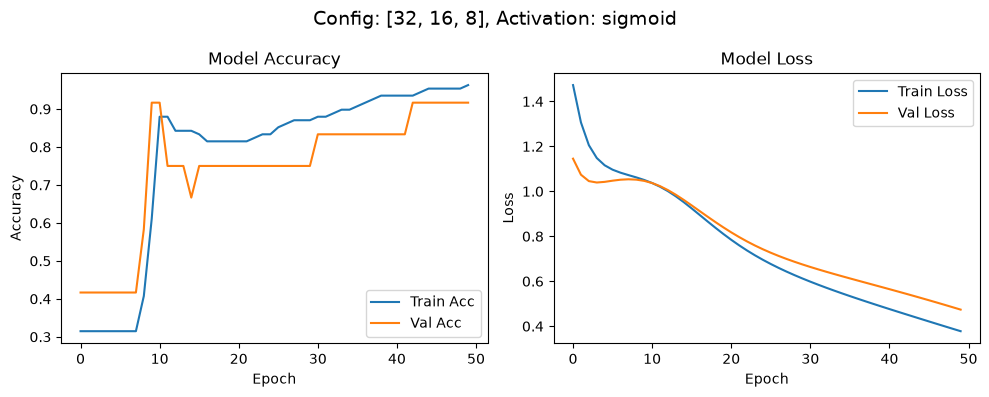

In [7]:
plt.figure(figsize=(10, 4))

plt.suptitle(
    f"Config: {hidden_layers}, Activation: {activation}",
    fontsize=14
)

# Accuracy plot
plt.subplot(1, 2, 1)

plt.plot(
    history.history['accuracy'],
    label='Train Acc'
)

plt.plot(
    history.history['val_accuracy'],
    label='Val Acc'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()


# Loss plot
plt.subplot(1, 2, 2)

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Val Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
sepal_length = float(input("Sepal length (cm): "))
sepal_width = float(input("Sepal width (cm): "))
petal_length = float(input("Petal length (cm): "))
petal_width = float(input("Petal width (cm): "))

user_input = np.array([
    [sepal_length, sepal_width, petal_length, petal_width]
])

user_input_scaled = scaler.transform(user_input)

# Predict using the last trained model
prediction = model.predict(user_input_scaled)

predicted_class_index = np.argmax(prediction)

predicted_class_name = classes[predicted_class_index]

print(f"\n🌸 Predicted Iris Species: {predicted_class_name}")